In [1]:
import pandas as pd 
import random
import networkx as nx
import matplotlib.pyplot as plt 
import numpy as np

Objectif : simuler un arbre pouvant représenter les maladies HPO et le représenter dans la disque de Poincaré.

In [2]:
N_NODES = 50
MAX_DEPTH = 5
N_DISEASES = 50
SEED = 42
RNG = random.Random(SEED)

def simulate_hpo_data(n_nodes, max_depth, dag_extra_edges_pct=0.10, rng=RNG):

    
    # Construction de l'arbre
    ROOT = "HP:0000001"
    G = nx.DiGraph()
    G.add_node(ROOT, depth=0)
    
    node_ids = [f"HP:{i:07d}" for i in range(2, n_nodes + 1)]
    for node_id in node_ids:
        G.add_node(node_id, depth=-1)
    
    by_depth = {0: [ROOT]}  # Dictionnaire contenant les noeuds par profondeur de l'arbre
    for node_id in node_ids:
        d = rng.randint(1, max_depth)  # On tire une profondeur au hasard
        parent_d = d - 1  # Profondeur du parent 
        if parent_d not in by_depth or not by_depth[parent_d]:  
            d, parent_d = 1, 0  # Cas où le parent est la racine
        parent = rng.choice(by_depth[parent_d])  # Tirage uniforme du parent parmi les candidats disponibles
        G.add_edge(node_id, parent)
        nx.set_node_attributes(G, {node_id: {"depth": d}})
        by_depth.setdefault(d, []).append(node_id)
    
    # Noeuds avec plusieurs parents
    n_extra = int(n_nodes * dag_extra_edges_pct)
    existing = set(G.edges())
    attempts = 0
    added = 0
    while added < n_extra and attempts < 1000:
        attempts += 1
        child = rng.choice(node_ids)
        child_depth = G.nodes[child].get("depth", 1)
        if child_depth < 2:
            continue
        parent_d = rng.randint(0, child_depth - 1)
        pool = by_depth.get(parent_d, [])
        if not pool:
            continue
        parent = rng.choice(pool)
        if (child, parent) not in existing:
            G.add_edge(child, parent)
            existing.add((child, parent))
            added += 1
    return G


G = simulate_hpo_data(n_nodes=N_NODES, max_depth=MAX_DEPTH)

print(f"Nœuds : {G.number_of_nodes()}")
print(f"Arêtes : {G.number_of_edges()}")

Nœuds : 50
Arêtes : 54


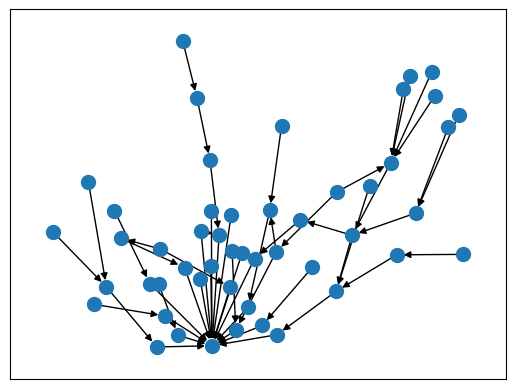

In [3]:
nx.draw_networkx(G, node_size= 100,with_labels=False)

### Algorithme de Sarkar 

In [ ]:
def mobius_add(u: np.ndarray, v: np.ndarray) -> np.ndarray:
    """Addition de Möbius dans le disque de Poincaré."""
    u2 = np.dot(u, u)
    v2 = np.dot(v, v)
    uv = np.dot(u, v)
    num = (1 + 2*uv + v2) * u + (1 - u2) * v
    denom = 1 + 2*uv + u2 * v2
    return num / denom

def sarkar_embed(G: nx.DiGraph, scale: float = 1.0) -> dict[str, np.ndarray]:
    """
    Embedding de Sarkar (2011) sur le spanning tree du DAG.
    Retourne {node_id: np.array([x, y])} avec ||coords|| < 1.
    """
    # Spanning tree par BFS depuis la racine
    root = "HP:0000001"
    spanning_tree = nx.bfs_tree(G.reverse(), root).reverse()

    coords = {root: np.array([0.0, 0.0])}
    
    def embed_children(node, parent, angle_start, angle_end):
        
        children = [n for n in spanning_tree.predecessors(node)
                    if n != parent]
        if not children:
            return
        
        n_children = len(children)
        angle_step = (angle_end - angle_start) / n_children
        
        # Rayon hyperbolique : tanh(scale/2)
        r = np.tanh(scale / 2)
        
        for i, child in enumerate(children):
            angle = angle_start + (i + 0.5) * angle_step
            
            # Position locale (dans le repère centré sur node)
            local_pos = r * np.array([np.cos(angle), np.sin(angle)])
            
            # Transport vers coordonnées globales via Möbius
            coords[child] = mobius_add(coords[node], local_pos)
            
            # Récursion sur le sous-cône angulaire
            embed_children(child, node, 
                           angle_start + i * angle_step,
                           angle_start + (i+1) * angle_step)
    
    embed_children(root, None, 0, 2 * np.pi)
    return coords

In [69]:
coord = sarkar_embed(G)

In [13]:
import plotly.graph_objects as go

def visualize_hpo_poincare(G: nx.DiGraph, coords: dict):
    
    fig = go.Figure()
    
    # --- Cercle unité (bord du disque) ---
    theta = np.linspace(0, 2*np.pi, 300)
    fig.add_trace(go.Scatter(
        x=np.cos(theta), y=np.sin(theta),
        mode='lines', line=dict(color='black', width=1),
        showlegend=False, hoverinfo='none'
    ))
    
    # --- Arêtes du DAG de fond (gris clair) ---
    for u, v in G.edges():
        if u in coords and v in coords:
            # Géodésique = arc de cercle dans le disque de Poincaré
            # Approximation: ligne droite (suffisant à cette échelle)
            x0, y0 = coords[u]
            x1, y1 = coords[v]
            fig.add_trace(go.Scatter(
                x=[x0, x1], y=[y0, y1],
                mode='lines',
                line=dict(color='lightgray', width=0.3),
                showlegend=False, hoverinfo='none'
            ))
    
    
    # --- Nœuds HPO (neutres, par-dessus) ---
    node_x = [coords[n][0] for n in G.nodes() if n in coords]
    node_y = [coords[n][1] for n in G.nodes() if n in coords]
    node_labels = [G.nodes[n].get('label', n) for n in G.nodes() if n in coords]
    
    fig.add_trace(go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        marker=dict(size=4, color='#333333'),
        text=node_labels,
        hovertemplate='%{text}<extra></extra>',
        showlegend=False
    ))
    
    fig.update_layout(
        title="HPO — Disque de Poincaré",
        width=900, height=900,
        xaxis=dict(range=[-1.05, 1.05], scaleanchor='y', showgrid=False),
        yaxis=dict(range=[-1.05, 1.05], showgrid=False),
        plot_bgcolor='white',
        legend=dict(itemclick='toggle', itemdoubleclick='toggleothers')
    )
    
    return fig

visualize_hpo_poincare(G, coord)

### Algorithme par Nickel et Kwela

In [50]:
# Fonctions utilitaires
def distance_poincare(u, v, eps=1e-12):

    arg = 1 + 2 * (np.linalg.norm(u-v)**2)/((1-np.linalg.norm(u)**2 + eps)*(1-np.linalg.norm(v)**2 + eps))
    return np.arccosh(arg)


def grad_distance_poincare(theta, x):

    alpha = 1-np.linalg.norm(theta)**2
    beta = 1-np.linalg.norm(x)**2
    gamma = 1+2*(np.linalg.norm(theta-x)**2)/(alpha*beta)

    term = theta*(np.linalg.norm(x)**2-2*np.dot(theta, x)+1)/alpha**2 - x/alpha

    return 4*term/(beta*np.sqrt(gamma**2-1))


def proj(theta, epsilon=1e-5):

    if np.linalg.norm(theta)>=1 :
        return theta/np.linalg.norm(theta)-epsilon
    
    return theta

def loss(u, v, vN, theta, eps=1e-12) :
    '''
    u, v : deux sommets reliés par une arête.
    vN : ensemble des sommets qui ne sont pas voisins de u.
    '''
    u_hyp = theta[u]
    v_hyp = theta[v]
    vN_hyp = theta[vN]

    dist_vN = np.array([distance_poincare(u_hyp,vn) for vn in vN_hyp])
    dist_v = distance_poincare(u_hyp, v_hyp)
    all_d  = np.concatenate([[dist_v], dist_vN])
    all_v = np.concatenate([[v_hyp], vN_hyp])

    scores = -all_d                              # plus petit = plus probable
    log_Z  = np.log(np.sum(np.exp(scores - scores.max())) + eps) + scores.max()
    loss   = -(scores[0] - log_Z)

    grad1_Z = np.array([grad_distance_poincare(u_hyp, vn) for vn in all_v])
    grad2_Z = np.exp(scores-scores.max())/np.sum(np.exp(scores-scores.max()))
    grad_uv = grad_distance_poincare(u_hyp, v_hyp)
    grad_u = -grad_uv + np.sum(grad2_Z[:,None]*grad1_Z, axis=0)

    return loss, grad_u

def sample_negatives(u_idx, n_nodes, n_neg=10, exclude=None):
    """
    Tire 10 vN au hasard en excluant les voisins connus.
    """
    exclude = exclude or set()
    exclude.add(u_idx)
    candidates = list(set(range(n_nodes)) - exclude)
    return np.random.choice(candidates, size=min(n_neg, len(candidates)),
                            replace=False)

In [59]:
def poincare_embeddings(rng, nodes, edges, dim, epochs, lr, burn_in=10, c=10) :

    n_nodes = len(nodes)
    neighbors = {i: set() for i in range(n_nodes)}
    for u, v in edges:
        neighbors[u].add(v)
        neighbors[v].add(u)
    
    # Initialisation 
    theta = rng.uniform(-0.001, 0.001, size = (n_nodes, dim))  # Ici a priori dim=2

    for epoch in range(epochs):
        total_loss = 0
        perm = rng.permutation(len(edges))
        for idx in perm : 
            u, v = edges[idx]
            vN = sample_negatives(u, n_nodes, 10, neighbors[u])
            l, grad_loss = loss(u, v, vN, theta)

            if epoch<=burn_in :
                lr_eff = lr/c
            else :
                lr_eff=lr
            arg = lr_eff * ((1-np.linalg.norm(theta[u])**2)**2)*grad_loss/4
            theta[u]-= arg
            theta[u] = proj(theta[u])

            total_loss += l
    return theta


In [63]:
node_list = list(G.nodes())
node_to_idx = {n: i for i, n in enumerate(node_list)}
edges_idx = [(node_to_idx[u], node_to_idx[v])
             for u, v in G.edges()
             if u in node_to_idx and v in node_to_idx]

rng = np.random.default_rng(SEED)
theta = poincare_embeddings(rng, node_to_idx, edges_idx, 2, 50, 1)

coords_nickel = {node_list[i]: theta[i] for i in range(len(node_list))}

C:\Users\auran\AppData\Local\Temp\ipykernel_5632\555676858.py:5: RuntimeWarning: invalid value encountered in arccosh
  return np.arccosh(arg)


In [57]:
coords_nickel

{'HP:0000001': array([ 0.80626173, -0.58713602]),
 'HP:0000002': array([-0.79163316,  0.60794255]),
 'HP:0000003': array([-0.79164785,  0.60799528]),
 'HP:0000004': array([ 0.80609097, -0.58707504]),
 'HP:0000005': array([-0.79154003,  0.60788009]),
 'HP:0000006': array([-0.79148113,  0.60780922]),
 'HP:0000007': array([-0.79166989,  0.60806764]),
 'HP:0000008': array([-0.79153511,  0.60783075]),
 'HP:0000009': array([ 0.80622122, -0.58717011]),
 'HP:0000010': array([-0.79143364,  0.60783688]),
 'HP:0000011': array([-0.79155518,  0.60791425]),
 'HP:0000012': array([-0.79153422,  0.60783011]),
 'HP:0000013': array([ 0.80574383, -0.58691229]),
 'HP:0000014': array([-0.79141522,  0.60776533]),
 'HP:0000015': array([-0.79154921,  0.60786677]),
 'HP:0000016': array([-0.79134322,  0.60775814]),
 'HP:0000017': array([-0.79161652,  0.60798891]),
 'HP:0000018': array([ 0.80598824, -0.58700215]),
 'HP:0000019': array([-0.79146494,  0.60781216]),
 'HP:0000020': array([-0.79163477,  0.60802247]),


In [68]:
def visualize_hpo_poincare(G: nx.DiGraph, coords: dict):
    
    fig = go.Figure()
    
    # --- Cercle unité (bord du disque) ---
    theta = np.linspace(0, 2*np.pi, 300)
    fig.add_trace(go.Scatter(
        x=np.cos(theta), y=np.sin(theta),
        mode='lines', line=dict(color='black', width=1),
        showlegend=False, hoverinfo='none'
    ))
    
    # --- Arêtes du DAG de fond (gris clair) ---
    for u, v in G.edges():
        if u in coords and v in coords:
            # Géodésique = arc de cercle dans le disque de Poincaré
            # Approximation: ligne droite (suffisant à cette échelle)
            x0, y0 = coords[u]
            x1, y1 = coords[v]
            fig.add_trace(go.Scatter(
                x=[x0, x1], y=[y0, y1],
                mode='lines',
                line=dict(color='lightgray', width=0.5),
                showlegend=False, hoverinfo='none'
            ))
    
    
    # --- Nœuds HPO (neutres, par-dessus) ---
    node_x = [coords[n][0] for n in G.nodes() if n in coords]
    node_y = [coords[n][1] for n in G.nodes() if n in coords]
    node_labels = [G.nodes[n].get('label', n) for n in G.nodes() if n in coords]
    
    fig.add_trace(go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        marker=dict(size=4, color='#333333'),
        text=node_labels,
        hovertemplate='%{text}<extra></extra>',
        showlegend=False
    ))
    
    fig.update_layout(
        title="HPO — Disque de Poincaré",
        width=900, height=900,
        xaxis=dict(range=[-1.05, 1.05], scaleanchor='y', showgrid=False),
        yaxis=dict(range=[-1.05, 1.05], showgrid=False),
        plot_bgcolor='white',
        legend=dict(itemclick='toggle', itemdoubleclick='toggleothers')
    )
    
    return fig

visualize_hpo_poincare(G, coords_nickel)

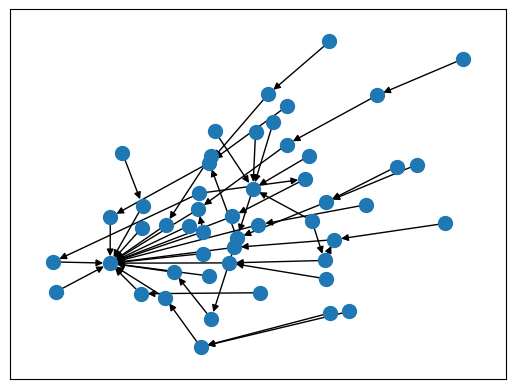

In [66]:
nx.draw_networkx(G, node_size= 100,with_labels=False)